# Fitting the logarithm of air density

This notebook uses air-density data to explore a central subtlety of **mathematical modeling**: transforming a variable changes the fitting problem. The scientific details of the atmosphere are secondary here; the density values are useful because they span several orders of magnitude.

The companion notebook `graph_air_density.ipynb` minimizes residuals in density, $\rho$. This notebook minimizes residuals in $\log(\rho)$. Those are not equivalent procedures. For a small residual,

$$\log(\rho_i)-\log(f_i)\approx\frac{\rho_i-f_i}{\rho_i},$$

so an unweighted log-space fit behaves approximately like a fit to **fractional** rather than absolute errors. Low-density points therefore retain influence instead of being overwhelmed by the much larger numerical values at low altitude.

We will compare four choices on the same plots: two fitting functions, each fitted with and without uncertainty weighting. This separates two independent modeling decisions: what family of curves to use and what loss function to minimize.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

## Choose the model family

The two choices correspond to

$$\log(\rho) = a + bh$$

and

$$\log(\rho) = a + bh + ch^{3/2}.$$

Exponentiating these equations gives the same two density-model families used in the original notebook:

$$\rho=e^a e^{bh}$$

and

$$\rho=e^a e^{bh+ch^{3/2}}.$$

The intercept $a$ is the logarithm of the density amplitude, so the amplitude itself is $e^a$. The second function has an extra adjustable parameter and can represent curvature in a plot of $\log(\rho)$ versus altitude. Greater flexibility usually lowers the residual sum of squares, but it can also fit noise or systematic effects. A smaller residual alone is therefore not sufficient evidence that a more complicated function is preferable.

In [26]:
def log_linear(x, a, b):
    return a + b*np.asarray(x)

def log_curved(x, a, b, c):
    x = np.asarray(x)
    return a + b*x + c*np.power(x, 1.5)

## Prepare containers for the data

The input file contains several columns. Only altitude and density enter the fits, but keeping explicitly named containers for every column makes the file structure and unit conversion easy to inspect.

In [27]:
altitude = []
temp = []
gravity = []
pressure = []
density = []
viscosity = []

## Read, scale, and transform the data

The density column is tabulated in units of $0.1\;\mathrm{kg/m^3}$ and is converted to $\mathrm{kg/m^3}$ before taking its logarithm. A logarithm requires positive inputs; all density values in this data set satisfy that requirement.

Strictly speaking, the logarithm of a dimensional quantity is understood here as $\log(\rho/[1\;\mathrm{kg/m^3}])$. Choosing a different reference unit would shift the fitted intercept but would not change the predicted physical densities.

In [28]:
npoints = 0
with open('density.txt') as f:
    for line in f:
        npoints += 1
        data = line.split()
        altitude.append(float(data[0]))
        temp.append(float(data[1]))
        gravity.append(float(data[2]))
        pressure.append(float(data[3]))
        # The density column is tabulated in units of 0.1 kg/m^3.
        density.append(0.1*float(data[4]))
        viscosity.append(float(data[5]))

altitude = np.asarray(altitude)
density = np.asarray(density)
log_density = np.log(density)

In [29]:
# Density uncertainties, in the table's units.
density_uncertainty = [0.01,0.01,0.01,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.0001,0.0001,0.0001,0.00001,0.00001,0.000001,0.0000001,0.0000001]

# Convert them to kg/m^3 and propagate them through log(rho):
# sigma_log(rho) = sigma_rho/rho.
density_uncertainty = 0.1*np.asarray(density_uncertainty)
log_density_uncertainty = density_uncertainty/density

Text(0, 0.5, '$\\log(\\rho/[1\\;\\mathrm{kg\\,m^{-3}}])$')

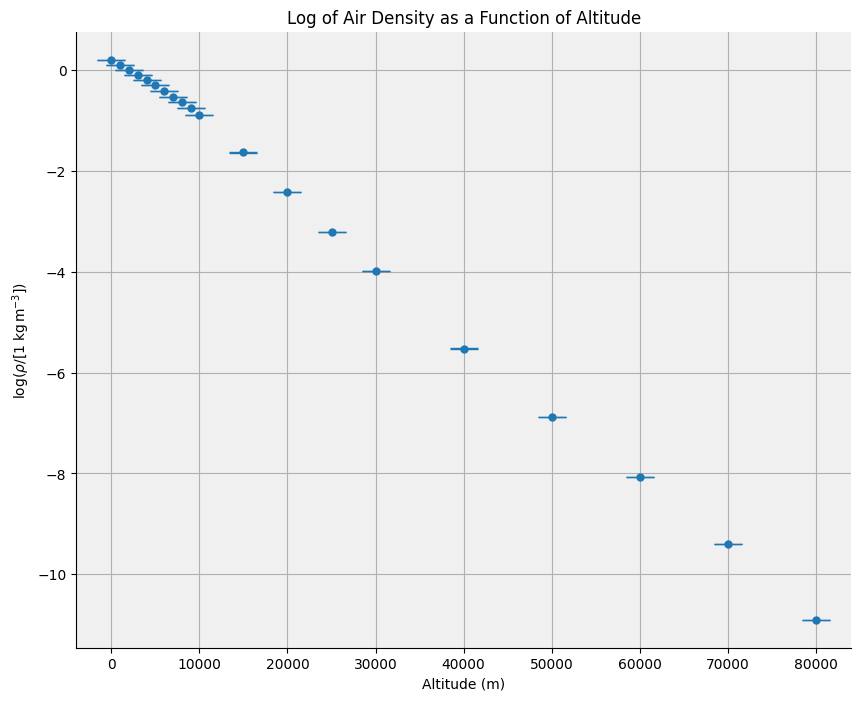

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)
ax.set_facecolor('#F0F0F0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.errorbar(altitude, log_density, yerr=log_density_uncertainty,
            linestyle='none', marker='o', markersize=5, capsize=10)

ax.set_title("Log of Air Density as a Function of Altitude")
ax.set_xlabel("Altitude (m)")
ax.set_ylabel(r"$\log(\rho/[1\;\mathrm{kg\,m^{-3}}])$")

## Fit all four modeling choices

For each function, the unweighted fit minimizes

$$S_{\log}=\sum_i[\log(\rho_i)-g(h_i)]^2,$$

where $g(h)$ is one of the log-density models above. Equal vertical distances in log space correspond to equal multiplicative factors: overpredicting by a factor of two and underpredicting by a factor of two have residuals of equal magnitude and opposite sign.

For the weighted fits, density uncertainties are propagated through the logarithm using the first-order approximation

$$\sigma_{\log\rho,i}\approx\left|\frac{d\log\rho}{d\rho}\right|\sigma_{\rho,i}=\frac{\sigma_{\rho,i}}{\rho_i}.$$

This approximation is appropriate when the relative uncertainties are small. The weighted objective is then

$$\chi^2_{\log}=\sum_i\left[\frac{\log(\rho_i)-g(h_i)}{\sigma_{\log\rho,i}}\right]^2.$$

A point's influence now depends on both the log transformation and its stated uncertainty. `absolute_sigma=True` treats the supplied uncertainties as absolute one-standard-deviation values when constructing the parameter covariance matrix. The diagonal elements of that matrix are estimated parameter variances, while off-diagonal elements describe parameter correlations.

Because these models are nonlinear in altitude but linear in their parameters once written in log space, the optimization is especially well behaved. We nevertheless provide initial parameter values, as is standard practice with `curve_fit`.

In [31]:
from scipy.optimize import curve_fit

model_definitions = {
    "Linear, unweighted": (log_linear, [np.log(1.2), -0.0001], False),
    "Linear, weighted": (log_linear, [np.log(1.2), -0.0001], True),
    r"Linear + $h^{3/2}$, unweighted":
        (log_curved, [np.log(1.2), -0.0001, -0.000001], False),
    r"Linear + $h^{3/2}$, weighted":
        (log_curved, [np.log(1.2), -0.0001, -0.000001], True),
}

fits = {}
for label, (function, init_vals, use_errors) in model_definitions.items():
    fit_arguments = {}
    if use_errors:
        fit_arguments = {"sigma": log_density_uncertainty,
                         "absolute_sigma": True}
    parameters, covariance = curve_fit(
        function, altitude, log_density, p0=init_vals, **fit_arguments
    )
    fits[label] = {"function": function,
                   "parameters": parameters,
                   "covariance": covariance,
                   "weighted": use_errors}

## Evaluate goodness of fit in the fitted space

A goodness-of-fit statistic must be interpreted in relation to the objective function. For weighted fits, the notebook reports $\chi^2$ and the number of degrees of freedom,

$$\nu=N-p,$$

where $N$ is the number of data points and $p$ is the number of fitted parameters. If the model is suitable, uncertainties are realistic and independent, and the usual statistical assumptions hold, $\chi^2/\nu$ is often expected to be of order one. A very large value may indicate model inadequacy, underestimated uncertainties, correlated errors, or some combination of these—not merely a failed optimizer.

For unweighted fits, the reported sum of squared log residuals is an optimization measure, not a statistical chi-square. It cannot be interpreted using the same reduced-chi-square rule because no measurement uncertainties appear in it. Also remember that the two functions use different numbers of parameters: the more flexible function has one fewer degree of freedom.

In [32]:
for label, result in fits.items():
    function = result["function"]
    parameters = result["parameters"]
    log_prediction = function(altitude, *parameters)
    result["log_prediction"] = log_prediction
    result["density_prediction"] = np.exp(log_prediction)
    dof = npoints - len(parameters)

    if result["weighted"]:
        statistic = np.sum(((log_density - log_prediction)/
                            log_density_uncertainty)**2)
        statistic_name = "chi^2"
    else:
        statistic = np.sum((log_density - log_prediction)**2)
        statistic_name = "sum of squared log residuals"

    print(label)
    print("  parameters:", parameters)
    print("  amplitude exp(a) = %.6g kg/m^3" % np.exp(parameters[0]))
    print("  %s / dof = %.3E / %d" %
          (statistic_name, statistic, dof))

Linear, unweighted
  parameters: [ 3.69950273e-01 -1.41490049e-04]
  amplitude exp(a) = 1.44766 kg/m^3
  sum of squared log residuals / dof = 2.650E-01 / 18
Linear, weighted
  parameters: [ 3.89077303e-01 -1.40470893e-04]
  amplitude exp(a) = 1.47562 kg/m^3
  chi^2 / dof = 3.361E+06 / 18
Linear + $h^{3/2}$, unweighted
  parameters: [ 3.90987052e-01 -1.45629254e-04  1.52243384e-08]
  amplitude exp(a) = 1.47844 kg/m^3
  sum of squared log residuals / dof = 2.601E-01 / 17
Linear + $h^{3/2}$, weighted
  parameters: [ 4.13354061e-01 -1.45332291e-04  1.77192860e-08]
  amplitude exp(a) = 1.51188 kg/m^3
  chi^2 / dof = 3.251E+06 / 17


## Compare all four fits visually

All four fitted curves are drawn with the same data. Color identifies the fitting function, while line style identifies whether uncertainties were included. A logarithmic density axis is natural for displaying the wide range, but the important distinction is that these parameters were obtained by fitting the logarithms—not simply by plotting a density-space fit on log axes.

The percentage-residual plot and log-residual plot provide closely related views for small discrepancies, but they need not agree when discrepancies are large. Look for systematic curvature, long sequences with the same sign, or altitude regions where one weighting choice performs much better than another. Such patterns reveal model mismatch that can be difficult to see when four smooth curves nearly overlap on the main graph.

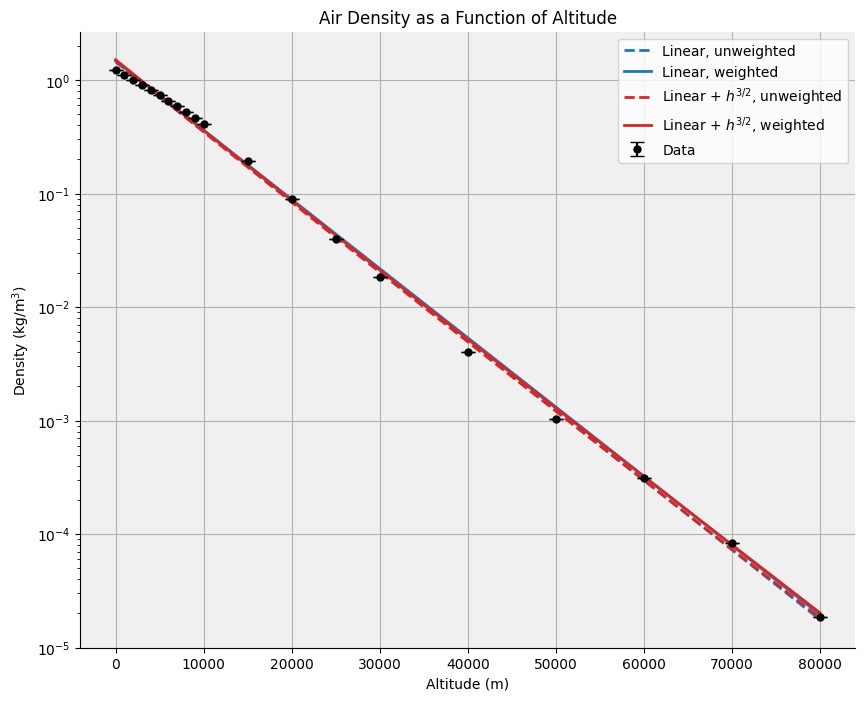

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)
ax.set_facecolor('#F0F0F0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.errorbar(altitude, density, yerr=density_uncertainty,
            color='black', linestyle='none', marker='o', markersize=5,
            capsize=5, label='Data', zorder=5)

plot_altitude = np.linspace(altitude.min(), altitude.max(), 500)
colors = {"log_linear": "tab:blue", "log_curved": "tab:red"}
for label, result in fits.items():
    function = result["function"]
    parameters = result["parameters"]
    line_style = '-' if result["weighted"] else '--'
    ax.plot(plot_altitude, np.exp(function(plot_altitude, *parameters)),
            color=colors[function.__name__], linestyle=line_style,
            linewidth=2, label=label)
ax.set_title("Air Density as a Function of Altitude")
ax.set_xlabel("Altitude (m)")
ax.set_ylabel(r"Density ($\mathrm{kg/m^3}$)")
ax.set_yscale('log')
ax.legend()

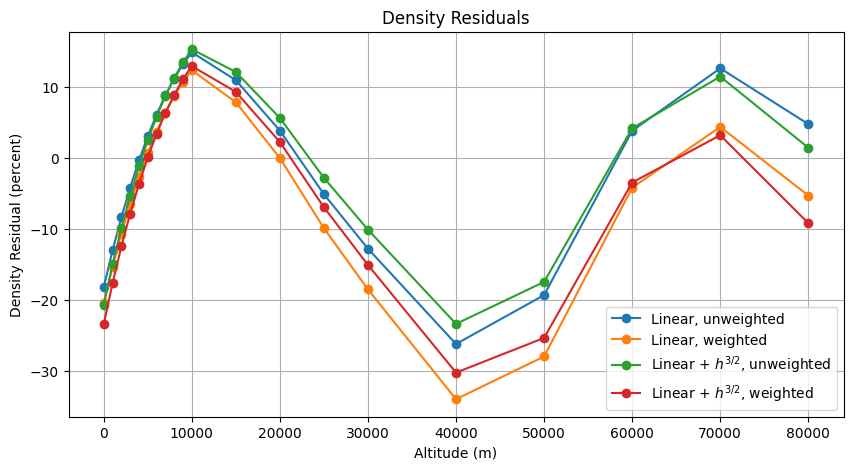

In [34]:
plt.figure(figsize=(10, 5))
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residual (percent)')
plt.grid(True)
for label, result in fits.items():
    plt.plot(altitude,
             (density - result["density_prediction"])/density*100,
             'o-', label=label)
plt.legend()

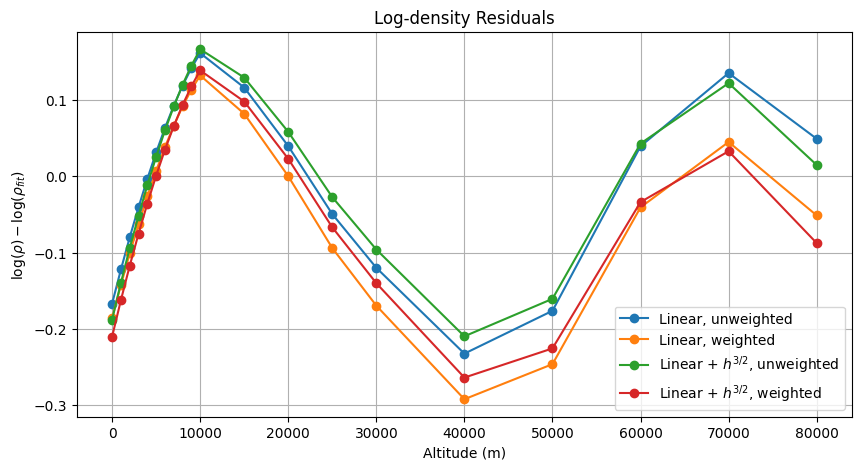

In [35]:
plt.figure(figsize=(10, 5))
plt.title("Log-density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel(r"$\log(\rho)-\log(\rho_{fit})$")
plt.grid(True)
for label, result in fits.items():
    plt.plot(altitude, log_density - result["log_prediction"],
             'o-', label=label)
plt.legend()

## Modeling lessons

This comparison illustrates several general principles that apply far beyond this data set:

- Choosing a dependent-variable transformation implicitly chooses which kinds of discrepancies matter most.
- Unweighted least squares and uncertainty-weighted $\chi^2$ minimization answer different statistical questions.
- Error bars affect parameter estimates only through an explicit weighting model; drawing error bars on a graph does not automatically use them in a fit.
- Transforming uncertainties requires propagation, and the approximation used should be checked against the size and form of the errors.
- A more flexible function can reduce residuals simply because it has more adjustable parameters.
- Residual patterns, parameter uncertainty and correlation, degrees of freedom, and the objective-function value all contribute different evidence about a model.

Most importantly, there is no uniquely neutral fit. The function, variable transformation, weighting, and assumptions about uncertainty jointly define the mathematical problem being solved.